Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
import joblib

Load Dataset

In [2]:
df = pd.read_csv("../datasets/diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Basic EDA

In [3]:
print(df.shape)

(100000, 9)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None


In [5]:
print(df.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [6]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [7]:
print(df.duplicated().sum())

3854


In [8]:
print(df["diabetes"].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


Remove Duplicate Data

In [9]:
df = df.drop_duplicates()
print(df.shape)

(96146, 9)


In [10]:
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')


Detailed EDA

Target Distribution

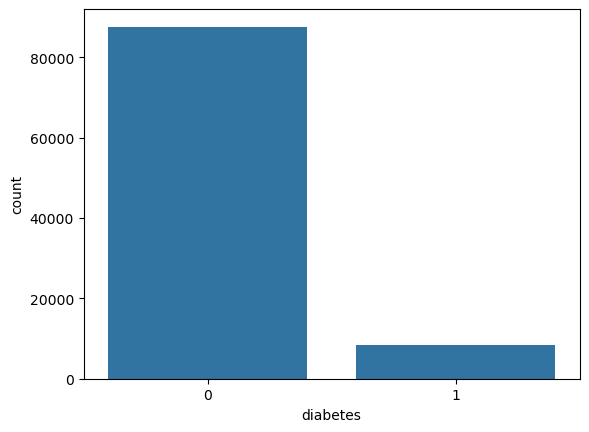

In [11]:
sns.countplot(x="diabetes", data=df)
plt.show()

Numerical Feature Distributions

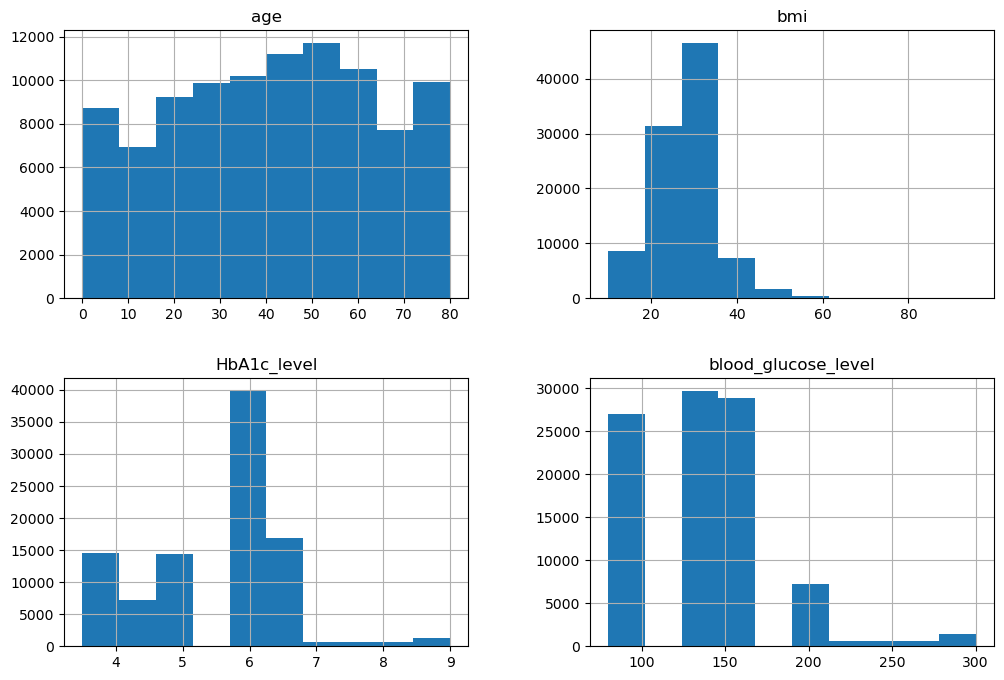

In [12]:
num_cols = ["age","bmi","HbA1c_level","blood_glucose_level"]

df[num_cols].hist(figsize=(12,8))
plt.show()

Correlation

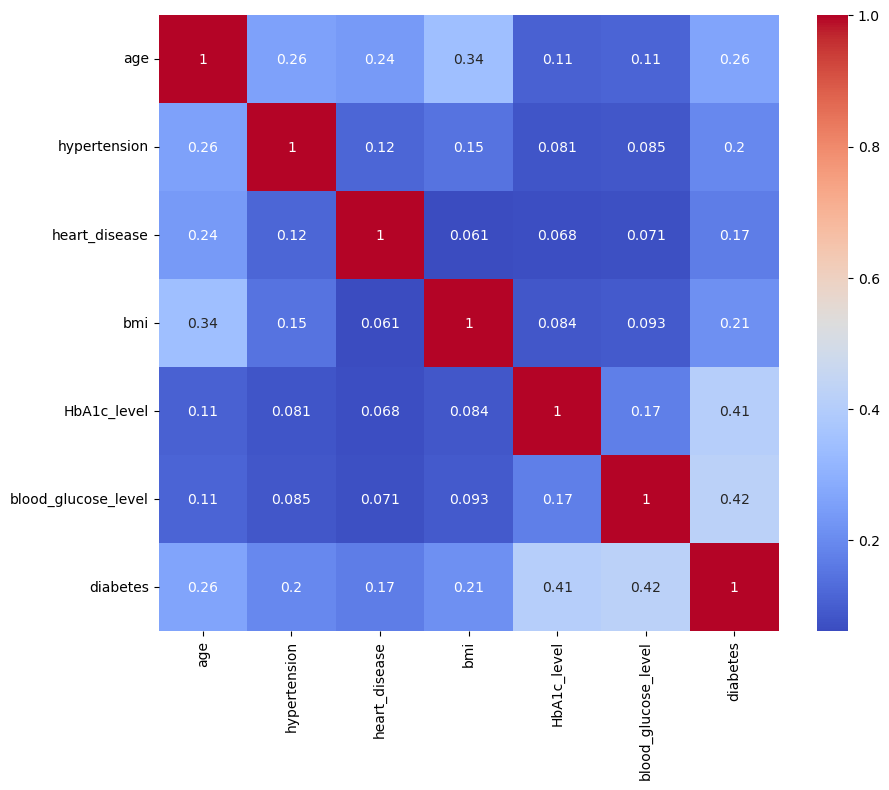

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

Boxplots (Outliers)

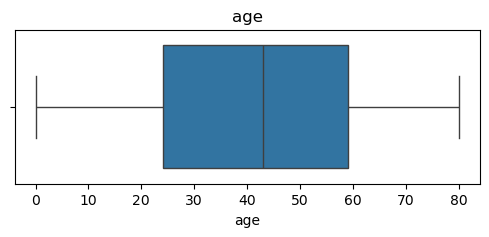

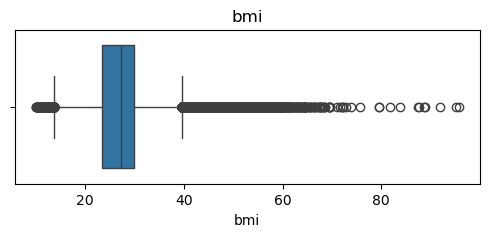

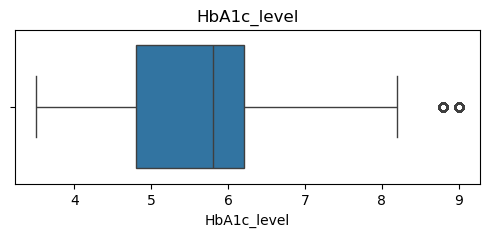

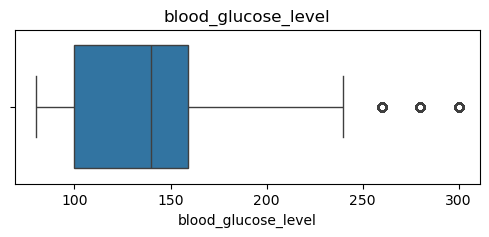

In [14]:
num_cols = ["age","bmi","HbA1c_level","blood_glucose_level"]

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Separate Features and Target

In [15]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Find Numerical,Categorical & Binary Columns

In [17]:
num_features = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

In [18]:
cat_features = [
    "gender",
    "smoking_history"
]

In [19]:
binary_features = [
    "hypertension",
    "heart_disease"
]

Preprocessing Pipeline

In [20]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
    ("bin", "passthrough", binary_features)
])

Transform Data

In [21]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

Check Shapes

In [22]:
print("X_train:", X_train_processed.shape)

print("X_test :", X_test_processed.shape)

X_train: (76916, 15)
X_test : (19230, 15)


Handle Class Imbalance

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [24]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
diabetes
0    70130
1     6786
Name: count, dtype: int64

After SMOTE:
diabetes
0    70130
1    70130
Name: count, dtype: int64


Create Model Dictionary

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    )
}

Train Every Model

In [26]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_processed)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training XGBoost...


Compare Models

In [27]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.968487,0.893218,0.729953,0.803374,0.975936
2,Random Forest,0.955642,0.746347,0.752948,0.749633,0.964334
0,Logistic Regression,0.883619,0.423099,0.879127,0.571264,0.960025
3,KNN,0.905720,0.479218,0.795401,0.598094,0.910823
1,Decision Tree,0.944098,0.659969,0.755307,0.704427,0.858970


In [28]:
# Training predictions
train_pred = models["XGBoost"].predict(X_train_smote)

# Test predictions
test_pred = models["XGBoost"].predict(X_test_processed)

print("Train Accuracy :", accuracy_score(y_train_smote, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))

Train Accuracy : 0.9737772707828319
Test Accuracy  : 0.9684867394695788


check the classification report

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, test_pred))

print(confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17534
           1       0.89      0.73      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.93      0.86      0.89     19230
weighted avg       0.97      0.97      0.97     19230

[[17386   148]
 [  458  1238]]


Save Model

In [30]:
joblib.dump(models["XGBoost"], "../models/diabetes_model.pkl")
joblib.dump(preprocessor, "../models/diabetes_preprocessor.pkl")

['../models/diabetes_preprocessor.pkl']

In [31]:
model = joblib.load("../models/diabetes_model.pkl")
preprocessor = joblib.load("../models/diabetes_preprocessor.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [32]:
import xgboost
print(xgboost.__version__)

3.2.0


In [33]:
import xgboost
import sklearn

print("XGBoost :", xgboost.__version__)
print("Scikit-learn :", sklearn.__version__)

XGBoost : 3.2.0
Scikit-learn : 1.9.0


In [34]:
import joblib

model = joblib.load("../models/diabetes_model.pkl")

print(type(model))

sample = X_test_processed[:5]

print(model.predict(sample))

<class 'xgboost.sklearn.XGBClassifier'>
[0 0 0 0 0]
